# **Infrastructure:**

In [3]:
# Block 1: Dependencies
!pip install stable-baselines3[extra] gymnasium shimmy matplotlib pandas numpy
import pandas as pd
import numpy as np
import gymnasium as gym
from stable_baselines3 import SAC
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 13.6 MB/s eta 0:00:00


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


# **The "Toxic" LOB Replayer:**

In this environment, "Toxicity" is an observable state. High toxicity means a price move is imminent.

In [4]:
class ToxicFlowEnv(gym.Env):
    def __init__(self, n_steps=1000):
        super().__init__()
        # Simulating a market where high 'toxicity' leads to a price drop
        self.df = pd.DataFrame({
            'mid': 100 + np.cumsum(np.random.normal(0, 0.2, n_steps)),
            'toxicity': np.random.uniform(0, 1, n_steps)
        })
        self.observation_space = gym.spaces.Box(low=-np.inf, high=np.inf, shape=(3,), dtype=np.float32)
        self.action_space = gym.spaces.Box(low=0.0, high=2.5, shape=(2,), dtype=np.float32)
        self.reset()

    def reset(self, seed=None):
        self.idx, self.inventory, self.cash = 0, 0, 0.0
        return self._get_obs(), {}

    def _get_obs(self):
        row = self.df.iloc[self.idx]
        return np.array([row['mid'], self.inventory, row['toxicity']], dtype=np.float32)

    def step(self, action):
        bid_d, ask_d = action
        row = self.df.iloc[self.idx]

        # Adverse Selection Logic:
        # If toxicity is high (>0.85), a massive sell order hits the bid and price drops.
        if row['toxicity'] > 0.85:
            price_impact = -0.75 # Sudden drop
            self.inventory += 1 # Agent forced into a long position as price crashes
            self.cash -= (row['mid'] - bid_d)
        else:
            price_impact = np.random.normal(0, 0.05)
            # Normal fill logic based on depth
            if np.random.random() < (0.5 - bid_d*0.2): self.inventory += 1; self.cash -= (row['mid'] - bid_d)
            if np.random.random() < (0.5 - ask_d*0.2): self.inventory -= 1; self.cash += (row['mid'] + ask_d)

        self.idx += 1
        new_price = row['mid'] + price_impact
        wealth = self.cash + (self.inventory * new_price)
        # Heavy penalty for inventory in toxic regimes
        reward = wealth - 0.5 * (self.inventory ** 2)

        return self._get_obs(), float(reward), (self.idx >= 999), False, {"wealth": wealth}

# **Training the Smart Agent (SAC):**

We use SAC because it is excellent at learning "risk-averse" policies in high-entropy environments.

In [5]:
# Block 3: Training
env_b = ToxicFlowEnv()
print("Training Agent B to identify and avoid Toxic Flow...")
model_b = SAC("MlpPolicy", env_b, verbose=1).learn(total_timesteps=25000)
print("Training Complete.")

Training Agent B to identify and avoid Toxic Flow...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 999      |
|    ep_rew_mean     | -9.7e+04 |
| time/              |          |
|    episodes        | 4        |
|    fps             | 79       |
|    time_elapsed    | 50       |
|    total_timesteps | 3996     |
| train/             |          |
|    actor_loss      | 2.57e+03 |
|    critic_loss     | 5.94e+04 |
|    ent_coef        | 2.97     |
|    ent_coef_loss   | -6.8     |
|    learning_rate   | 0.0003   |
|    n_updates       | 3895     |
---------------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 999      |
|    ep_rew_mean     | 2.53e+04 |
| time/              |          |
|    episodes        | 8        |
|    fps             | 75       |
|    time_elapsed    | 105      |
|    total_timesteps | 7992     |
| train/             |          |
|    actor_loss      | -654     |
|    critic_loss     | 8.19e+04 |
|    ent_coef        | 8.88     |
|    ent_coef_loss   | -9.18    |
|    learning_rate   | 0.0003   |
|    n_updates       | 7891     |
---------------------------------
----------------------------------
| rollout/           |           |
|    ep_len_mean     | 999       |
|    ep_rew_mean     | 8.82e+04  |
| time/              |           |
|    episodes        | 12        |
|    fps             | 75        |
|    time_elapsed    | 159       |
|    total_timesteps | 11988     |
| train/             |           |
|    actor_loss      | -2.85e+03 |
|    critic_loss     | 1.04e+05  |
| 

# **Live Survival Dashboard:**

Watch the red markers on the price chart. Those are "Toxic Events." A smart agent will pull its green bid dot away from the price when it sees the toxicity bar spike.

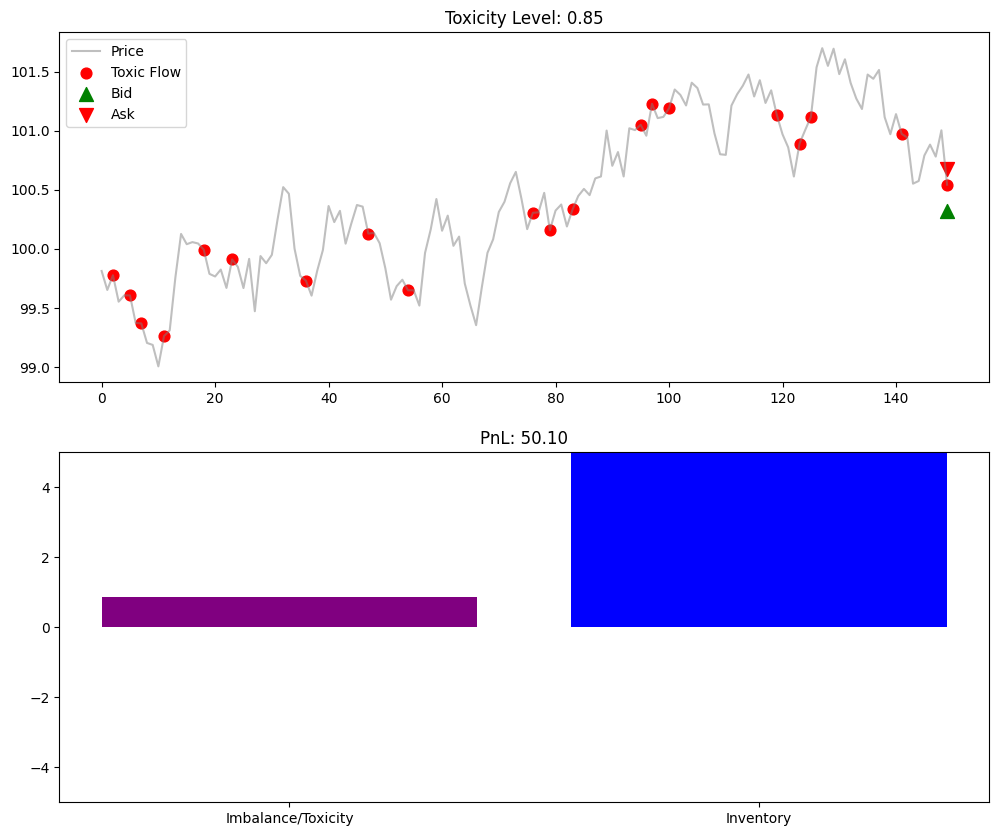

In [6]:
# Block 4: Toxic Survival Dashboard
obs, _ = env_b.reset()
prices, toxic_events, wealths = [], [], []

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

for i in range(150):
    action, _ = model_b.predict(obs, deterministic=True)
    obs, _, done, _, info = env_b.step(action)

    prices.append(obs[0]); wealths.append(info['wealth'])
    toxic_marker = obs[0] if obs[2] > 0.85 else np.nan
    toxic_events.append(toxic_marker)

    ax1.clear(); ax2.clear()
    ax1.plot(prices, color='gray', alpha=0.5, label="Price")
    ax1.scatter(range(len(prices)), toxic_events, color='red', label="Toxic Flow", s=60)
    ax1.scatter(len(prices)-1, obs[0] - action[0], color='green', marker='^', s=100, label='Bid')
    ax1.scatter(len(prices)-1, obs[0] + action[1], color='red', marker='v', s=100, label='Ask')
    ax1.set_title(f"Toxicity Level: {obs[2]:.2f}")
    ax1.legend()

    ax2.bar(["Imbalance/Toxicity", "Inventory"], [obs[2], obs[1]], color=['purple', 'blue'])
    ax2.set_ylim(-5, 5)
    ax2.set_title(f"PnL: {info['wealth']:.2f}")

    display(fig); clear_output(wait=True); time.sleep(0.04)
    if done: break